
# Transformer didáctico para pronóstico de la siguiente palabra

Notebook ejemplo de uso de la arquitectura *transformer* para el problema de **predicción de la siguiente palabra**.

## Objetivo
A partir del texto corto:

> **"Papá quiere a la niña. La niña quiere a mamá. Mamá quiere a la niña. La niña quiere"**

entrenaremos un modelo *transformer* para predecir la siguiente palabra/token y después haremos **generación autoregresiva** de **tres pasos**:

1. predecir la palabra más probable tras la frase semilla,
2. añadir esa palabra al contexto,
3. volver a predecir,
4. repetir hasta obtener tres tokens.

## Nota de diseño
Se conserva la idea principal de tu arquitectura original:

- `LayerNormalization`
- `MultiHeadAttention`
- `Dropout`
- conexión residual
- bloque `Conv1D` como *feed-forward network*
- `GlobalAveragePooling1D`
- capas densas finales

En comparación con el uso de *transformer* para el pronóstico de series temporales, la adaptación más importante es que, en lugar de una salida escalar de regresión, ahora usamos una **salida softmax sobre el vocabulario**.

## Importar librerías

In [ ]:

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Embedding,
    LayerNormalization,
    MultiHeadAttention,
    Convolution1D,
    GlobalAveragePooling1D,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0



## 1. Corpus didáctico

Usaremos exactamente el texto proporcionado. Para evitar ambigüedades, convertimos todo a minúsculas y separamos el punto `.` como token independiente.


In [ ]:
raw_text = "Papá quiere a la niña. La niña quiere a mamá. Mamá quiere a la niña. La niña quiere"
text = raw_text.lower()

def tokenize_spanish(text):
    return re.findall(r"\w+|[.]", text, flags=re.UNICODE)

tokens = tokenize_spanish(text)
print("Tokens del corpus:")
print(tokens)
print("Número total de tokens:", len(tokens))


Tokens del corpus:
['papá', 'quiere', 'a', 'la', 'niña', '.', 'la', 'niña', 'quiere', 'a', 'mamá', '.', 'mamá', 'quiere', 'a', 'la', 'niña', '.', 'la', 'niña', 'quiere']
Número total de tokens: 21



## 2. Vocabulario

Añadimos un token de relleno (`<pad>`) para poder igualar longitudes de secuencia.


In [ ]:
pad_token = "<pad>"
vocab = [pad_token] + sorted(set(tokens))
word_to_id = {word: idx for idx, word in enumerate(vocab)}
id_to_word = {idx: word for word, idx in word_to_id.items()}

print("Vocabulario:", vocab)
print("Tamaño del vocabulario:", len(vocab))
print("Vocabulario por idenficador",word_to_id)
print("Id. por palabra",id_to_word)

Vocabulario: ['<pad>', '.', 'a', 'la', 'mamá', 'niña', 'papá', 'quiere']
Tamaño del vocabulario: 8
Vocabulario por idenficador {'<pad>': 0, '.': 1, 'a': 2, 'la': 3, 'mamá': 4, 'niña': 5, 'papá': 6, 'quiere': 7}
Id. por palabra {0: '<pad>', 1: '.', 2: 'a', 3: 'la', 4: 'mamá', 5: 'niña', 6: 'papá', 7: 'quiere'}



## 3. Construcción del conjunto de entrenamiento

Entrenaremos con una estrategia muy simple y útil:

- cada ejemplo de entrada es un **prefijo** del texto,
- la etiqueta es el **siguiente token**.

Por ejemplo:

- entrada: `papá`  → salida: `quiere`
- entrada: `papá quiere` → salida: `a`
- entrada: `papá quiere a` → salida: `la`

Así el modelo aprende el problema autoregresivo clásico de *next-token prediction*.


In [ ]:
encoded_corpus = [word_to_id[token] for token in tokens]
encoded_corpus

[6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3, 5, 1, 3, 5, 7]

In [ ]:
input_sequences = []
target_tokens = []
for i in range(1, len(encoded_corpus)):
    input_sequences.append(encoded_corpus[:i])
    target_tokens.append(encoded_corpus[i])

print('input',input_sequences)
print('target',target_tokens)

input [[6], [6, 7], [6, 7, 2], [6, 7, 2, 3], [6, 7, 2, 3, 5], [6, 7, 2, 3, 5, 1], [6, 7, 2, 3, 5, 1, 3], [6, 7, 2, 3, 5, 1, 3, 5], [6, 7, 2, 3, 5, 1, 3, 5, 7], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3, 5], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3, 5, 1], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3, 5, 1, 3], [6, 7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3, 5, 1, 3, 5]]
target [7, 2, 3, 5, 1, 3, 5, 7, 2, 4, 1, 4, 7, 2, 3, 5, 1, 3, 5, 7]


In [ ]:
max_len = max(len(seq) for seq in input_sequences)
X = pad_sequences(input_sequences, maxlen=max_len, padding="pre", value=word_to_id[pad_token])
y = np.array(target_tokens, dtype=np.int32)

print("Forma de X:", X.shape)
print("X:",X)
print("Forma de y:", y.shape)
print("Y:",y)
print("Longitud máxima de secuencia:", max_len)

Forma de X: (20, 20)
X: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6 7]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6 7 2]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6 7 2 3]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 6 7 2 3 5]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 6 7 2 3 5 1]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 6 7 2 3 5 1 3]
 [0 0 0 0 0 0 0 0 0 0 0 0 6 7 2 3 5 1 3 5]
 [0 0 0 0 0 0 0 0 0 0 0 6 7 2 3 5 1 3 5 7]
 [0 0 0 0 0 0 0 0 0 0 6 7 2 3 5 1 3 5 7 2]
 [0 0 0 0 0 0 0 0 0 6 7 2 3 5 1 3 5 7 2 4]
 [0 0 0 0 0 0 0 0 6 7 2 3 5 1 3 5 7 2 4 1]
 [0 0 0 0 0 0 0 6 7 2 3 5 1 3 5 7 2 4 1 4]
 [0 0 0 0 0 0 6 7 2 3 5 1 3 5 7 2 4 1 4 7]
 [0 0 0 0 0 6 7 2 3 5 1 3 5 7 2 4 1 4 7 2]
 [0 0 0 0 6 7 2 3 5 1 3 5 7 2 4 1 4 7 2 3]
 [0 0 0 6 7 2 3 5 1 3 5 7 2 4 1 4 7 2 3 5]
 [0 0 6 7 2 3 5 1 3 5 7 2 4 1 4 7 2 3 5 1]
 [0 6 7 2 3 5 1 3 5 7 2 4 1 4 7 2 3 5 1 3]
 [6 7 2 3 5 1 3 5 7 2 4 1 4 7 2 3 5 1 3 5]]
Forma de y: (20,)
Y: [7 2 3 5 1 3 5 7 2 4 1 4 7 2 3 5 1 3 5 7]
Longitud máxima de secuencia: 20


In [26]:
examples_df = pd.DataFrame({
    "entrada_tokens": [" ".join(id_to_word[idx] for idx in seq if idx != 0) for seq in X[:8]],
    "objetivo": [id_to_word[idx] for idx in y[:8]],
})

examples_df


ValueError: All arrays must be of the same length


## 4. Capa de embedding de token + posición

Como en cualquier transformer, necesitamos:

- una representación para el token,
- una representación para la posición dentro de la secuencia.


In [ ]:
class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

    def get_config(self):
        config = super().get_config()
        config.update({
            "maxlen": self.maxlen,
            "vocab_size": self.vocab_size,
            "embed_dim": self.embed_dim,
        })
        return config


## 5. Bloque transformer
Este bloque conserva la estructura del notebook de series temporales:

1. normalización,
2. auto-atención multi-cabeza,
3. *dropout* y residual,
4. red *feed-forward* implementada con `Conv1D(kernel_size=1)`,
5. segunda conexión residual.

In [ ]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.0):
    # Normalization and Attention
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
    )(x, x)
    x = Dropout(dropout)(x)
    res = x + inputs

    # Feed Forward Part (igual filosofía que en tu notebook)
    x = LayerNormalization(epsilon=1e-6)(res)
    x = Convolution1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = Dropout(dropout)(x)
    x = Convolution1D(filters=inputs.shape[-1], kernel_size=1)(x)
    return x + res


## 6. Modelo completo

Diferencias respecto al notebook de series temporales:

- la entrada ahora son índices enteros de tokens,
- la salida es un vector de tamaño `vocab_size`,
- se usa `softmax` para obtener probabilidades sobre la siguiente palabra.


In [ ]:

def build_model(
    input_shape,
    vocab_size,
    embed_dim,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0.0,
    mlp_dropout=0.0,
):
    inputs = Input(shape=input_shape, dtype="int32")
    x = TokenAndPositionEmbedding(input_shape[0], vocab_size, embed_dim)(inputs)
    print(x.shape)
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    x = GlobalAveragePooling1D()(x)

    for dim in mlp_units:
        x = Dense(dim, activation="relu")(x)
        x = Dropout(mlp_dropout)(x)

    outputs = Dense(vocab_size, activation="softmax")(x)
    return Model(inputs, outputs)

model = build_model(
    input_shape=(max_len,),
    vocab_size=len(vocab),
    embed_dim=32,
    head_size=16,
    num_heads=4,
    ff_dim=32,
    num_transformer_blocks=4,
    mlp_units=[32],
    dropout=0.10,
    mlp_dropout=0.10,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


(None, 20, 32)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 20, 32)    │        896 │ input_layer[0][0] │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 32)    │         64 │ token_and_positi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 32)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 20, 32)    │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 20, 32)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 20, 32)    │      1,056 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 32)    │          0 │ conv1d_1[0][0],   │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 32)    │      8,416 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 20, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 32)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 20, 32)    │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 20, 32)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 20, 32)    │      1,056 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 44,840 (175.16 KB)

 Trainable params: 44,840 (175.16 KB)

 Non-trainable params: 0 (0.00 B)


## 7. Entrenamiento

Como el corpus es diminuto y el objetivo es meramente didáctico, entrenamos muchas épocas para que el modelo memorice el patrón.


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True,
    )
]

In [ ]:
history = model.fit(
    X,
    y,
    epochs=400,
    batch_size=4,
    verbose=0,
    callbacks=callbacks,
)

print("Épocas entrenadas:", len(history.history["loss"]))
print("Loss final:", history.history["loss"][-1])
print("Accuracy final:", history.history["accuracy"][-1])


Épocas entrenadas: 57
Loss final: 0.4165709614753723
Accuracy final: 0.8500000238418579


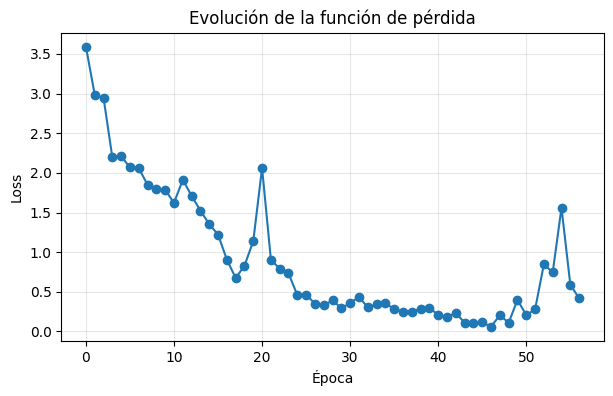

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], marker="o")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de la función de pérdida")
plt.grid(True, alpha=0.3)
plt.show()



## 8. Funciones auxiliares para predicción autoregresiva

Partimos de la frase semilla:

> **"La niña quiere"**

y generamos tres pasos. En cada iteración:

1. se calcula la distribución de probabilidad de la siguiente palabra,
2. se toma la palabra más probable (*greedy decoding*),
3. se añade al contexto,
4. se vuelve a predecir.


In [ ]:

def encode_text(text, word_to_id):
    tokens = tokenize_spanish(text.lower())
    ids = []
    for token in tokens:
        if token not in word_to_id:
            raise ValueError(f"Token desconocido para este vocabulario didáctico: {token!r}")
        ids.append(word_to_id[token])
    return tokens, ids


def predict_distribution(model, text, word_to_id, id_to_word, max_len, top_k=6):
    context_tokens, context_ids = encode_text(text, word_to_id)
    padded = pad_sequences([context_ids], maxlen=max_len, padding="pre", value=word_to_id[pad_token])
    probs = model.predict(padded, verbose=0)[0]

    ranked_ids = np.argsort(probs)[::-1]
    ranked_ids = [idx for idx in ranked_ids if idx != word_to_id[pad_token]]
    top_ids = ranked_ids[:top_k]

    top_words = [id_to_word[idx] for idx in top_ids]
    top_probs = [float(probs[idx]) for idx in top_ids]

    return {
        "context_tokens": context_tokens,
        "top_words": top_words,
        "top_probs": top_probs,
        "predicted_word": top_words[0],
        "predicted_prob": top_probs[0],
    }


def autoregressive_forecast(model, seed_text, steps, word_to_id, id_to_word, max_len, top_k=6):
    current_text = seed_text
    results = []

    for step in range(1, steps + 1):
        result = predict_distribution(model, current_text, word_to_id, id_to_word, max_len, top_k=top_k)
        print("result predict", result)
        result["step"] = step
        result["input_text"] = current_text
        results.append(result)
        current_text = current_text + " " + result["predicted_word"]

    return results, current_text



## 9. Pronóstico de tres palabras


In [ ]:

seed_text = "La niña quiere"
results, final_text = autoregressive_forecast(
    model=model,
    seed_text=seed_text,
    steps=3,
    word_to_id=word_to_id,
    id_to_word=id_to_word,
    max_len=max_len,
    top_k=6,
)

summary_rows = []
for result in results:
    summary_rows.append({
        "paso": result["step"],
        "contexto_entrada": result["input_text"],
        "palabra_predicha": result["predicted_word"],
        "probabilidad": result["predicted_prob"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


result predict {'context_tokens': ['la', 'niña', 'quiere'], 'top_words': ['a', 'niña', 'la', '.', 'quiere', 'mamá'], 'top_probs': [0.9999961853027344, 3.767217549466295e-06, 1.4764808299594367e-12, 7.365982823692718e-14, 1.958957316963356e-16, 2.5731241317946265e-17], 'predicted_word': 'a', 'predicted_prob': 0.9999961853027344}
result predict {'context_tokens': ['la', 'niña', 'quiere', 'a'], 'top_words': ['la', 'mamá', 'niña', '.', 'quiere', 'a'], 'top_probs': [0.6569697856903076, 0.34010595083236694, 0.0028363477904349566, 5.800591316074133e-05, 2.6069623345392756e-05, 3.7380905268946663e-06], 'predicted_word': 'la', 'predicted_prob': 0.6569697856903076}
result predict {'context_tokens': ['la', 'niña', 'quiere', 'a', 'la'], 'top_words': ['niña', 'mamá', 'a', 'la', 'quiere', '.'], 'top_probs': [1.0, 2.3099341106558313e-08, 4.298787888157296e-13, 1.328389167328664e-13, 3.2594458002858234e-14, 2.7620050344068225e-15], 'predicted_word': 'niña', 'predicted_prob': 1.0}


,paso,contexto_entrada,palabra_predicha,probabilidad
0,1,La niña quiere,a,0.999996
1,2,La niña quiere a,la,0.656970
2,3,La niña quiere a la,niña,1.000000


In [ ]:

print("Frase semilla:", seed_text)
print("Texto tras 3 pasos:", final_text)


Frase semilla: La niña quiere
Texto tras 3 pasos: La niña quiere a la niña



## 10. Gráficas de probabilidad para cada paso

Se genera una gráfica en cada iteración con las palabras más probables. Después se incorpora automáticamente la palabra más probable al contexto y se repite el proceso.


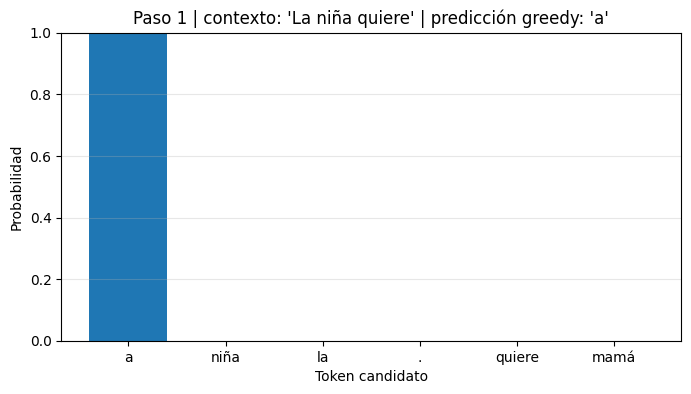

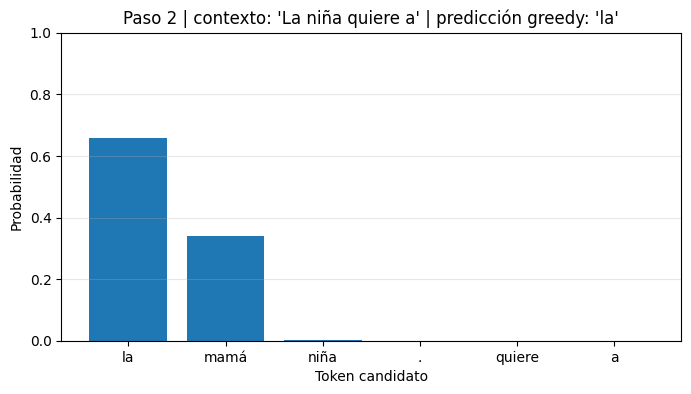

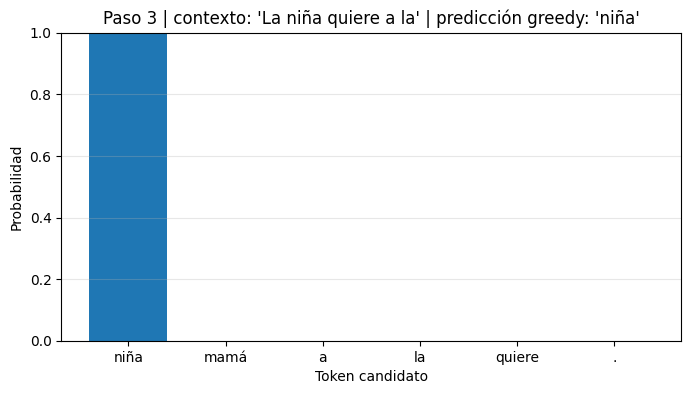

In [ ]:

for result in results:
    plt.figure(figsize=(8, 4))
    plt.bar(result["top_words"], result["top_probs"])
    plt.ylim(0, 1)
    plt.xlabel("Token candidato")
    plt.ylabel("Probabilidad")
    plt.title(
        f"Paso {result['step']} | contexto: '{result['input_text']}' | predicción greedy: '{result['predicted_word']}'"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.show()



## 11. Interpretación esperada

Con un corpus tan pequeño, el modelo no aprende gramática general del español; aprende principalmente los patrones del texto de entrenamiento. Eso es precisamente lo útil en un contexto docente, porque permite observar con claridad:

- cómo se construyen los ejemplos de entrada/salida,
- cómo se usa un bloque transformer para modelar secuencias,
- cómo una distribución `softmax` sobre el vocabulario produce la siguiente palabra,
- y cómo funciona la generación autoregresiva paso a paso.

## Posibles extensiones para clase

1. añadir más frases al corpus,
2. comparar `greedy decoding` frente a *sampling*,
3. predecir no solo palabras sino también signos de puntuación,
4. sustituir el `GlobalAveragePooling1D` por la extracción del último estado,
5. introducir una máscara causal explícita.


## Proceso de transformación de una palabra a Embedding

El camino que sigue la palabra **'papá'** es:
1. **Tokenización**: El texto se limpia y se separa en unidades (tokens).
2. **Indexación**: Se busca el ID numérico en el diccionario `word_to_id`.
3. **Proyección (Embedding)**: Ese ID actúa como índice para extraer una fila (un vector de pesos) de la matriz interna de la capa `token_emb`.

In [ ]:
# Verification of required variables from Sections 2 and 6
try:
    # 1. Identify the word and its ID
    word = "papá"
    word_id = word_to_id[word]
    print(f"Palabra: '{word}' -> ID numérico: {word_id}")

    # 2. Access the embedding layer from the trained model
    # model.layers[1] is the TokenAndPositionEmbedding layer
    embedding_layer = model.layers[1]

    # 3. Extract the weights from the token embedding matrix
    weights = embedding_layer.token_emb.get_weights()[0]

    # 4. Get the specific vector for 'papá'
    word_vector_papa = weights[word_id]

    print(f"\nVector de embedding (dimensión {len(word_vector_papa)}):")
    print(word_vector_papa)

except NameError as e:
    print(f"Error: {e}.")
    print("Por favor, ejecuta primero las celdas de las secciones:\n- 2. Vocabulario (celda c9c43dde)\n- 6. Modelo completo (celda 270a2fdc)")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Palabra: 'papá' -> ID numérico: 6

Vector de embedding (dimensión 32):
[-0.1580843   0.1326896   0.3224233  -0.06496973  0.13528447 -0.05265456
 -0.12097781  0.07345727 -0.14503421 -0.21958439  0.13401209  0.11071855
 -0.35040578  0.2101778   0.12682013 -0.01696816  0.11098047  0.21594244
 -0.40872487  0.02392345  0.02312618 -0.05717935 -0.12370101  0.06113188
 -0.06721248  0.0640761   0.09540422  0.05031241 -0.02092831  0.02119318
  0.19026932 -0.2399247 ]


In [ ]:
# Verification of required variables from Sections 2 and 6
try:
    # 1. Identify the word and its ID
    word = "mamá"
    word_id = word_to_id[word]
    print(f"Palabra: '{word}' -> ID numérico: {word_id}")

    # 2. Access the embedding layer from the trained model
    # model.layers[1] is the TokenAndPositionEmbedding layer
    embedding_layer = model.layers[1]

    # 3. Extract the weights from the token embedding matrix
    weights = embedding_layer.token_emb.get_weights()[0]

    # 4. Get the specific vector for 'papá'
    word_vector_mama = weights[word_id]

    print(f"\nVector de embedding (dimensión {len(word_vector_mama)}):")
    print(word_vector_mama)

except NameError as e:
    print(f"Error: {e}.")
    print("Por favor, ejecuta primero las celdas de las secciones:\n- 2. Vocabulario (celda c9c43dde)\n- 6. Modelo completo (celda 270a2fdc)")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Palabra: 'mamá' -> ID numérico: 4

Vector de embedding (dimensión 32):
[-0.05936525  0.04922271  0.23902884 -0.1298122   0.03103349 -0.00949682
 -0.1446498  -0.20351724 -0.05405997 -0.07122891 -0.03505835 -0.04765305
 -0.08909584  0.2411422   0.16364841 -0.01575584  0.22839883  0.06386813
 -0.31211248  0.1480139  -0.07726763  0.08479977 -0.16838513  0.13998297
 -0.09391757  0.20768335 -0.11993649 -0.18838094  0.09309801  0.07397594
  0.15763438 -0.01141076]


In [ ]:
# Verification of required variables from Sections 2 and 6
try:
    # 1. Identify the word and its ID
    word = "a"
    word_id = word_to_id[word]
    print(f"Palabra: '{word}' -> ID numérico: {word_id}")

    # 2. Access the embedding layer from the trained model
    # model.layers[1] is the TokenAndPositionEmbedding layer
    embedding_layer = model.layers[1]

    # 3. Extract the weights from the token embedding matrix
    weights = embedding_layer.token_emb.get_weights()[0]

    # 4. Get the specific vector for 'papá'
    word_vector_a = weights[word_id]

    print(f"\nVector de embedding (dimensión {len(word_vector_a)}):")
    print(word_vector_a)

except NameError as e:
    print(f"Error: {e}.")
    print("Por favor, ejecuta primero las celdas de las secciones:\n- 2. Vocabulario (celda c9c43dde)\n- 6. Modelo completo (celda 270a2fdc)")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Palabra: 'a' -> ID numérico: 2

Vector de embedding (dimensión 32):
[ 0.23593436  0.23235843  0.00598206  0.0863027   0.04970845  0.00447098
  0.14356372 -0.36476678 -0.10501617 -0.16042191 -0.07765437 -0.05291729
  0.22299884  0.02865057 -0.11781841 -0.05527158 -0.07477476  0.11939881
 -0.27367017 -0.15159304 -0.13570122  0.03935897  0.23409005 -0.13826597
  0.02478359 -0.15149231  0.05835479 -0.20394751  0.18954822 -0.19962293
  0.04152336  0.15046565]


In [ ]:
# Verification of required variables from Sections 2 and 6
try:
    # 1. Identify the word and its ID
    word = "."
    word_id = word_to_id[word]
    print(f"Palabra: '{word}' -> ID numérico: {word_id}")

    # 2. Access the embedding layer from the trained model
    # model.layers[1] is the TokenAndPositionEmbedding layer
    embedding_layer = model.layers[1]

    # 3. Extract the weights from the token embedding matrix
    weights = embedding_layer.token_emb.get_weights()[0]

    # 4. Get the specific vector for 'papá'
    word_vector_punto = weights[word_id]

    print(f"\nVector de embedding (dimensión {len(word_vector_punto)}):")
    print(word_vector_punto)

except NameError as e:
    print(f"Error: {e}.")
    print("Por favor, ejecuta primero las celdas de las secciones:\n- 2. Vocabulario (celda c9c43dde)\n- 6. Modelo completo (celda 270a2fdc)")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Palabra: '.' -> ID numérico: 1

Vector de embedding (dimensión 32):
[ 0.19139092  0.09023261 -0.09930817  0.00623211 -0.20173022  0.06490548
  0.18734215 -0.34103197 -0.03747381  0.0055645  -0.26372546 -0.0612244
  0.37231886  0.10978008 -0.07390874 -0.18983157 -0.09742606 -0.00812512
 -0.20287348 -0.00939335 -0.35970917  0.08679571  0.10929286 -0.07765345
  0.02274116 -0.06367957 -0.01675873 -0.30570433  0.21494876 -0.01789354
 -0.1737054   0.18882458]


In [ ]:
# Calcula Euclidean distances betwee: word_vector_papa and word_vector_mama
from scipy.spatial.distance import euclidean
euclidean_distance = euclidean(word_vector_papa, word_vector_mama)
print(f"Distancia Euclidiana entre word_vector_papa y word_vector_mama': {euclidean_distance}")

euclidean_distance = euclidean(word_vector_papa, word_vector_a)
print(f"Distancia Euclidiana entre word_vector_papa y word_vector_a': {euclidean_distance}")

euclidean_distance = euclidean(word_vector_papa, word_vector_punto)
print(f"Distancia Euclidiana entre word_vector_papa y word_vector_punto': {euclidean_distance}")

Distancia Euclidiana entre word_vector_papa y word_vector_mama': 0.7525159120559692
Distancia Euclidiana entre word_vector_papa y word_vector_a': 1.320715069770813
Distancia Euclidiana entre word_vector_papa y word_vector_punto': 1.571274757385254
